In [1]:
!pip install tensorflow matplotlib numpy

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
!pip install kagglehub

In [7]:
import kagglehub

path = kagglehub.dataset_download("salader/dogsvscats")

print("https://www.kaggle.com/datasets/salader/dogsvscats?resource=download", path)

Using Colab cache for faster access to the 'dogsvscats' dataset.
https://www.kaggle.com/datasets/salader/dogsvscats?resource=download /kaggle/input/dogsvscats


In [8]:
print(os.listdir(path))

['test', 'train', 'catsvsdogs']


In [9]:
for root, dirs, files in os.walk(path):
    print(root)
    print("Folders:", dirs)
    print("Files:", len(files))

/kaggle/input/dogsvscats
Folders: ['test', 'train', 'catsvsdogs']
Files: 0
/kaggle/input/dogsvscats/test
Folders: ['dogs', 'cats']
Files: 0
/kaggle/input/dogsvscats/test/dogs
Folders: []
Files: 2500
/kaggle/input/dogsvscats/test/cats
Folders: []
Files: 2500
/kaggle/input/dogsvscats/train
Folders: ['dogs', 'cats']
Files: 0
/kaggle/input/dogsvscats/train/dogs
Folders: []
Files: 10000
/kaggle/input/dogsvscats/train/cats
Folders: []
Files: 10000
/kaggle/input/dogsvscats/catsvsdogs
Folders: ['test', 'train']
Files: 0
/kaggle/input/dogsvscats/catsvsdogs/test
Folders: ['dogs', 'cats']
Files: 0
/kaggle/input/dogsvscats/catsvsdogs/test/dogs
Folders: []
Files: 2500
/kaggle/input/dogsvscats/catsvsdogs/test/cats
Folders: []
Files: 2500
/kaggle/input/dogsvscats/catsvsdogs/train
Folders: ['dogs', 'cats']
Files: 0
/kaggle/input/dogsvscats/catsvsdogs/train/dogs
Folders: []
Files: 10000
/kaggle/input/dogsvscats/catsvsdogs/train/cats
Folders: []
Files: 10000


In [10]:
train_dir = os.path.join(path, "train")
test_dir = os.path.join(path, "test")

img_size = (128, 128)
batch_size = 32

In [11]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True
)

Found 20000 files belonging to 2 classes.


In [12]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

Found 5000 files belonging to 2 classes.


In [13]:
print(train_dataset.class_names)

['cats', 'dogs']


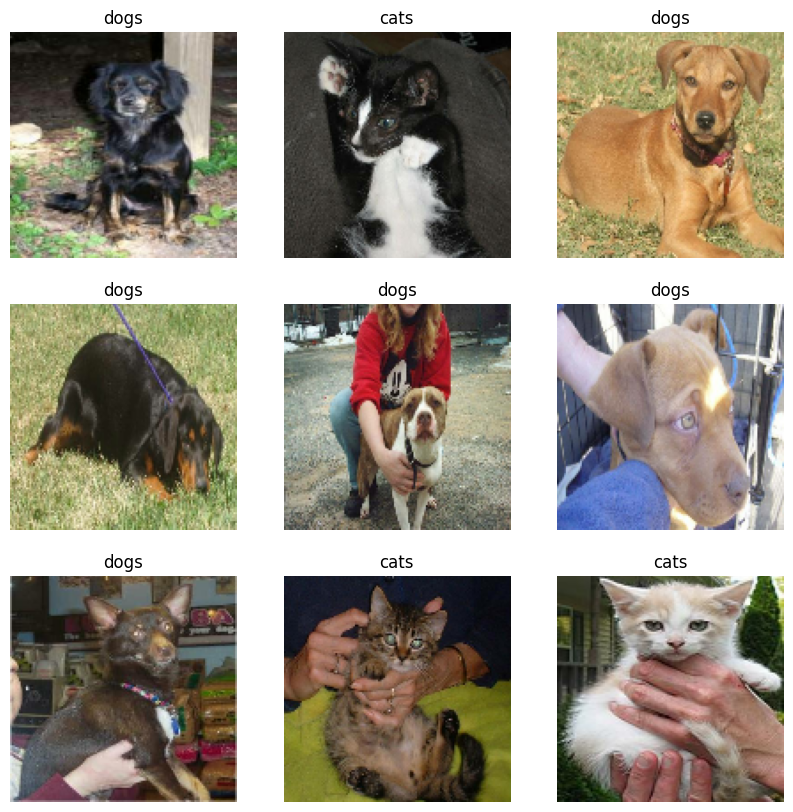

In [14]:
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_dataset.class_names[labels[i]])
        plt.axis("off")

plt.show()

In [15]:
normalization_layer = tf.keras.layers.Rescaling(
    1./255
)

In [16]:
model = tf.keras.Sequential([

    tf.keras.layers.Rescaling(1./255, input_shape=(128, 128, 3)),

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation="relu"),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [20]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=10
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 70s 101ms/step - accuracy: 0.6269 - loss: 0.6391 - val_accuracy: 0.7352 - val_loss: 0.5420
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.7535 - loss: 0.5029 - val_accuracy: 0.7992 - val_loss: 0.4459
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 49ms/step - accuracy: 0.8018 - loss: 0.4286 - val_accuracy: 0.8310 - val_loss: 0.3857
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.8401 - loss: 0.3611 - val_accuracy: 0.8352 - val_loss: 0.3739
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.8702 - loss: 0.2966 - val_accuracy: 0.8422 - val_loss: 0.3908
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.8968 - loss: 0.2443 - val_accuracy: 0.8394 - val_loss: 0.4275
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.9210 - loss: 0.1957 - val_accuracy: 0.8354 - val_loss: 0.4392
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.9401 - loss: 0.1546 -

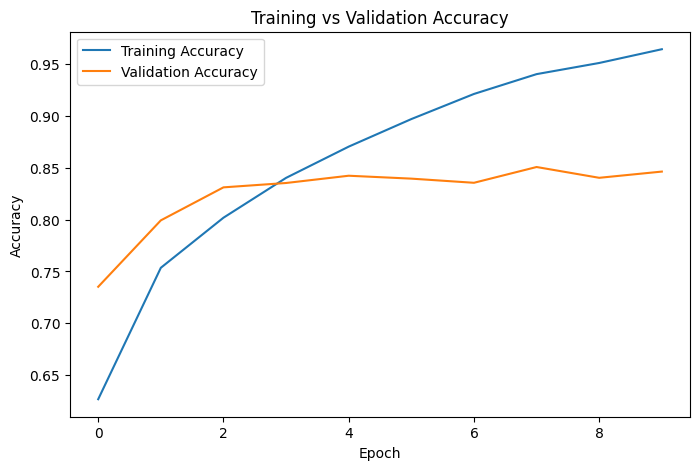

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

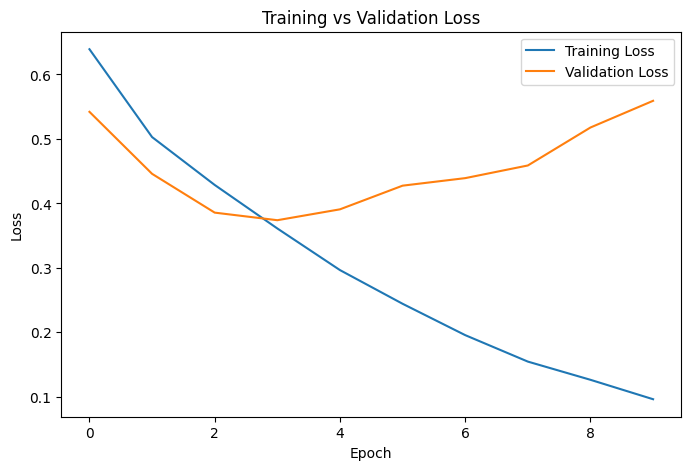

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [23]:
loss, accuracy = model.evaluate(test_dataset)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.8462 - loss: 0.5591
Test Loss: 0.5591374635696411
Test Accuracy: 0.8461999893188477


In [46]:
from google.colab import files

uploaded = files.upload()

Saving 16.png to 16.png


In [47]:
image_path = list(uploaded.keys())[0]

In [48]:
img = tf.keras.utils.load_img(
    image_path,
    target_size=(128, 128)
)

In [49]:
img_array = tf.keras.utils.img_to_array(img)

img_array = tf.expand_dims(
    img_array,
    0
)

In [50]:
prediction = model.predict(img_array)[0][0]

print("Prediction value:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Prediction value: 1.0


In [53]:
if prediction >= 0.5:
    confidence = prediction * 100
    print(f"🐶 Dog ({confidence:.2f}% confidence)")
else:
    confidence = (1 - prediction) * 100
    print(f"🐱 Cat ({confidence:.2f}% confidence)")

🐶 Dog (100.00% confidence)


In [54]:
model.save("dogs_vs_cats_cnn.keras")